Importing Libraries

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

In [2]:
DATA_DIR = Path("../data/raw/chest_xray")

TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

print("Dataset path:", DATA_DIR)
print("Train path:", TRAIN_DIR)
print("Validation path:", VAL_DIR)
print("Test path:", TEST_DIR)

Dataset path: ..\data\raw\chest_xray
Train path: ..\data\raw\chest_xray\train
Validation path: ..\data\raw\chest_xray\val
Test path: ..\data\raw\chest_xray\test


In [3]:
def count_images(folder):
    return len(list(folder.glob("*.jpeg"))) + len(list(folder.glob("*.jpg")))

for split, folder in {
    "Train": TRAIN_DIR,
    "Validation": VAL_DIR,
    "Test": TEST_DIR
}.items():

    normal = count_images(folder / "NORMAL")
    pneumonia = count_images(folder / "PNEUMONIA")

    print(f"{split}:")
    print(f"  Normal: {normal}")
    print(f"  Pneumonia: {pneumonia}")
    print(f"  Total: {normal + pneumonia}")
    print()

Train:
  Normal: 1341
  Pneumonia: 3875
  Total: 5216

Validation:
  Normal: 8
  Pneumonia: 8
  Total: 16

Test:
  Normal: 234
  Pneumonia: 390
  Total: 624



In [4]:
data = []

for split, folder in {
    "Train": TRAIN_DIR,
    "Validation": VAL_DIR,
    "Test": TEST_DIR
}.items():

    normal = count_images(folder / "NORMAL")
    pneumonia = count_images(folder / "PNEUMONIA")

    data.append([split, "NORMAL", normal])
    data.append([split, "PNEUMONIA", pneumonia])

df = pd.DataFrame(data, columns=["Split", "Class", "Count"])

df

,Split,Class,Count
0,Train,NORMAL,1341
1,Train,PNEUMONIA,3875
2,Validation,NORMAL,8
3,Validation,PNEUMONIA,8
4,Test,NORMAL,234
5,Test,PNEUMONIA,390


In [5]:
import random

def get_random_images(folder, n=5):
    images = list(folder.glob("*.jpeg")) + list(folder.glob("*.jpg"))
    return random.sample(images, min(n, len(images)))


normal_images = get_random_images(TRAIN_DIR / "NORMAL", 5)
pneumonia_images = get_random_images(TRAIN_DIR / "PNEUMONIA", 5)

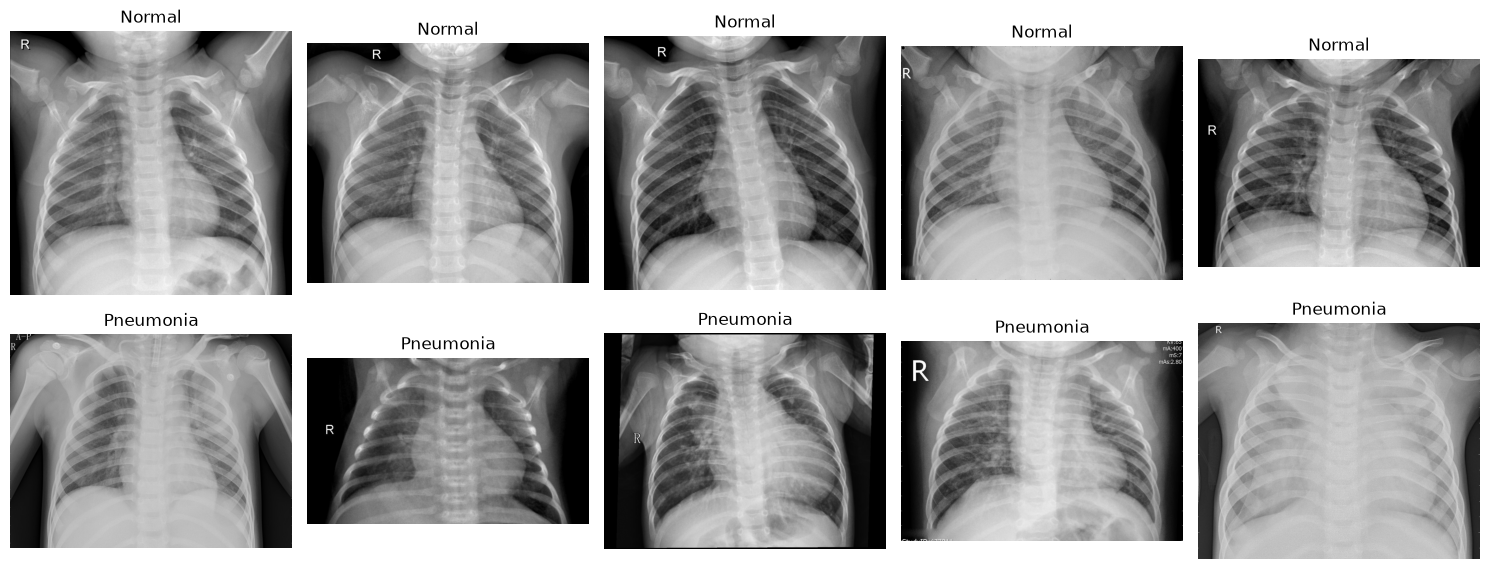

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, image_path in enumerate(normal_images):
    image = Image.open(image_path)
    axes[0, i].imshow(image, cmap="gray")
    axes[0, i].set_title("Normal")
    axes[0, i].axis("off")

for i, image_path in enumerate(pneumonia_images):
    image = Image.open(image_path)
    axes[1, i].imshow(image, cmap="gray")
    axes[1, i].set_title("Pneumonia")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()


In [7]:
# Inspect image properties

sample_images = normal_images[:3] + pneumonia_images[:3]

for image_path in sample_images:
    image = Image.open(image_path)

    print(f"File: {image_path.name}")
    print(f"Size: {image.size}")
    print(f"Mode: {image.mode}")
    print(f"Format: {image.format}")
    print("-" * 40)

File: NORMAL2-IM-0474-0001.jpeg
Size: (1728, 1619)
Mode: L
Format: JPEG
----------------------------------------
File: IM-0278-0001.jpeg
Size: (1766, 1503)
Mode: L
Format: JPEG
----------------------------------------
File: NORMAL2-IM-1190-0001.jpeg
Size: (1746, 1576)
Mode: L
Format: JPEG
----------------------------------------
File: person1638_bacteria_4340.jpeg
Size: (1976, 1496)
Mode: L
Format: JPEG
----------------------------------------
File: person45_bacteria_222.jpeg
Size: (1040, 615)
Mode: L
Format: JPEG
----------------------------------------
File: person1014_bacteria_2945.jpeg
Size: (1366, 1044)
Mode: L
Format: JPEG
----------------------------------------


In [8]:
from collections import Counter

def get_image_sizes(folder):
    sizes = []

    for image_path in folder.glob("*.jpeg"):
        with Image.open(image_path) as img:
            sizes.append(img.size)

    for image_path in folder.glob("*.jpg"):
        with Image.open(image_path) as img:
            sizes.append(img.size)

    return sizes


train_normal_sizes = get_image_sizes(TRAIN_DIR / "NORMAL")
train_pneumonia_sizes = get_image_sizes(TRAIN_DIR / "PNEUMONIA")

all_sizes = train_normal_sizes + train_pneumonia_sizes

print("Total images analyzed:", len(all_sizes))
print("Unique image sizes:", len(set(all_sizes)))
print("Most common sizes:")

for size, count in Counter(all_sizes).most_common(10):
    print(size, "→", count)

Total images analyzed: 5216
Unique image sizes: 4366
Most common sizes:
(1072, 648) → 7
(1080, 728) → 6
(1008, 680) → 5
(976, 672) → 5
(1216, 872) → 5
(992, 592) → 5
(1064, 760) → 5
(1008, 704) → 5
(1304, 968) → 4
(1088, 712) → 4


In [9]:
import numpy as np

sample_path = normal_images[0]

with Image.open(sample_path) as img:
    image_array = np.array(img)

print("Image:", sample_path.name)
print("Shape:", image_array.shape)
print("Minimum pixel value:", image_array.min())
print("Maximum pixel value:", image_array.max())
print("Mean pixel value:", image_array.mean())
print("Standard deviation:", image_array.std())

Image: NORMAL2-IM-0474-0001.jpeg
Shape: (1619, 1728)
Minimum pixel value: 0
Maximum pixel value: 255
Mean pixel value: 139.38457774289114
Standard deviation: 57.18554756097164


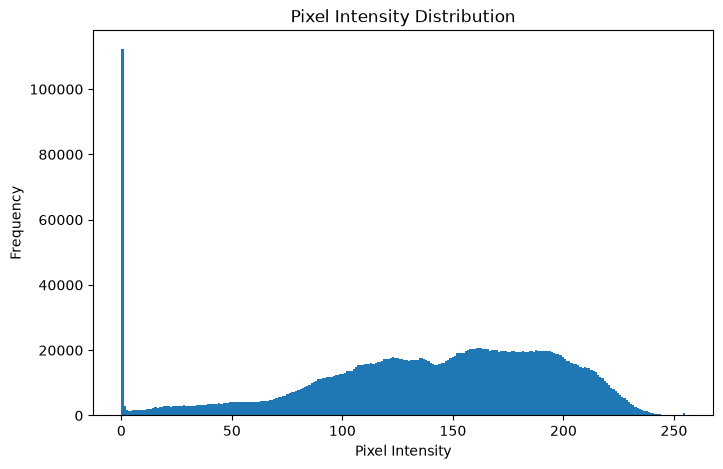

In [10]:
plt.figure(figsize=(8, 5))

plt.hist(image_array.ravel(), bins=256)

plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.show()

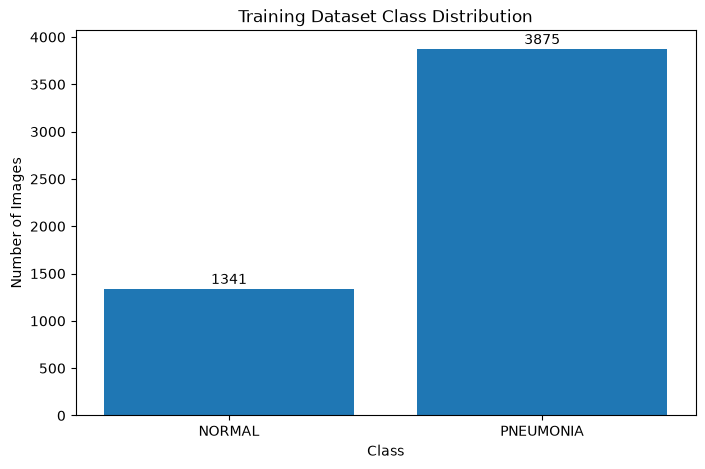

In [11]:
# Class distribution

class_counts = {
    "NORMAL": len(list((TRAIN_DIR / "NORMAL").glob("*.jpeg"))) +
              len(list((TRAIN_DIR / "NORMAL").glob("*.jpg"))),

    "PNEUMONIA": len(list((TRAIN_DIR / "PNEUMONIA").glob("*.jpeg"))) +
                 len(list((TRAIN_DIR / "PNEUMONIA").glob("*.jpg")))
}

plt.figure(figsize=(8, 5))

plt.bar(class_counts.keys(), class_counts.values())

plt.title("Training Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

for i, value in enumerate(class_counts.values()):
    plt.text(i, value + 50, str(value), ha="center")

plt.show()

Exploratory analysis revealed a substantial class imbalance in the training dataset, with pneumonia cases accounting for 74.29% of the images compared with 25.71% normal cases. Therefore, class imbalance mitigation and appropriate evaluation metrics are considered during model development

Data Preparation